# 2022111723 데이터사이언스학과 김경은
CNN Fine Tuning

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import random

In [2]:
def load_dataset():
    # Set dataset path
    dataset_path = './data/svhn'

    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4377, 0.4438, 0.4728), (0.1980, 0.2010, 0.1970)),
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4377, 0.4438, 0.4728), (0.1980, 0.2010, 0.1970)),
    ])

    # Load SVHN dataset
    trainset = torchvision.datasets.SVHN(root=dataset_path, split='train',
                                         download=True, transform=transform_train)

    trainloader = torch.utils.data.DataLoader(trainset, batch_size=64,
                                              shuffle=True, num_workers=4)

    testset = torchvision.datasets.SVHN(root=dataset_path, split='test',
                                        download=True, transform=transform_test)
    testloader = torch.utils.data.DataLoader(testset, batch_size=64,
                                             shuffle=False, num_workers=4)

    # Class names for SVHN dataset
    classes = ('0', '1', '2', '3', '4', '5', '6', '7', '8', '9')

    return trainset, trainloader, testset, testloader, classes

In [3]:
def train(model, trainloader, criterion, optimizer, device):
    train_loss = 0.0
    train_total = 0
    train_correct = 0

    # Switch to train mode
    model.train()

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Update training loss
        train_loss += loss.item() * inputs.size(0)

        # Compute training accuracy
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    # Compute average training loss and accuracy
    train_loss = train_loss / len(trainloader.dataset)
    train_accuracy = 100.0 * train_correct / train_total

    return model, train_loss, train_accuracy

In [4]:
def test(model, testloader, criterion, device):
    test_loss = 0.0
    test_total = 0
    test_correct = 0

    # Switch to evaluation mode
    model.eval()

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Update test loss
            test_loss += loss.item() * inputs.size(0)

            # Compute test accuracy
            _, predicted = torch.max(outputs, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    # Compute average test loss and accuracy
    test_loss = test_loss / len(testloader.dataset)
    test_accuracy = 100.0 * test_correct / test_total

    return test_loss, test_accuracy

In [5]:
def train_epochs(model, trainloader, testloader, criterion, optimizer, device, num_epochs, save_interval=5):
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        model, train_loss, train_accuracy = train(model, trainloader, criterion, optimizer, device)
        test_loss, test_accuracy = test(model, testloader, criterion, device)

        print(f'Train Loss: {train_loss:.4f} - Train Accuracy: {train_accuracy:.2f}%')
        print(f'Test Loss: {test_loss:.4f} - Test Accuracy: {test_accuracy:.2f}%')

        if (epoch + 1) % save_interval == 0:
            # Save the model and variables
            torch.save(model.state_dict(), f'densenet121_svhn_{epoch+1}.pth')

    return model

In [6]:
def plot_image(dataset, model, classes):
    idx = random.randint(1, len(dataset))
    print("idx=", idx)
    label = dataset[idx][1]
    img = dataset[idx][0].unsqueeze(0).to(device)  # Move the input image tensor to the GPU
    model.eval()

    with torch.no_grad():
        output = model(img)
        _, predicted = torch.max(output.data, 1)
        print(predicted, label)

    # Convert the image and show it
    img = img.squeeze().permute(1, 2, 0).cpu()  # Move the image tensor back to the CPU and adjust dimensions
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Predicted: {classes[predicted]}, True: {classes[label]}')
    plt.show()

In [7]:
if __name__ == '__main__':
    # Flag to control whether to run training or use saved fine-tuned model.
    train_model = True

    # Number of classes
    num_classes = 10

    # Import DenseNet model pretrained on ImageNet
    model = models.densenet121(pretrained=True)
    print("Network before modifying classifier:")
    print(model.classifier)

    # Modify conv1 to suit SVHN
    model.features[0] = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)

    # Modify the classifier to suit SVHN
    num_features = model.classifier.in_features
    model.classifier = nn.Linear(num_features, num_classes)
    print("Network after modifying classifier:")
    print(model.classifier)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 238MB/s]

Network before modifying classifier:
Linear(in_features=1024, out_features=1000, bias=True)
Network after modifying classifier:
Linear(in_features=1024, out_features=10, bias=True)


In [8]:
    # Move the model to GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    num_epochs = 10

    if train_model:
        # Define loss function and optimizer
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.99), eps=1e-08, weight_decay=1e-5)  # Adam optimizer for better performance

        # Load the dataset
        trainset, trainloader, testset, testloader, classes = load_dataset()

        # Train the model for N epochs, saving every m epochs
        save_interval = 3
        model = train_epochs(
            model, trainloader, testloader, criterion, optimizer, device,
            num_epochs, save_interval)

        # Save the final trained model
        torch.save(model.state_dict(), f'densenet121_svhn_final_model_epochs_{num_epochs}.pth')

    else:
        # Load the pre-trained model
        model.load_state_dict(torch.load(f'densenet121_svhn_final_model_epochs_{num_epochs}.pth'))
        model.eval()

100%|██████████| 182M/182M [00:32<00:00, 5.66MB/s]
100%|██████████| 64.3M/64.3M [00:12<00:00, 5.21MB/s]


Epoch 1/10
Train Loss: 0.5947 - Train Accuracy: 81.28%
Test Loss: 0.3666 - Test Accuracy: 88.74%
Epoch 2/10
Train Loss: 0.3525 - Train Accuracy: 89.55%
Test Loss: 0.2618 - Test Accuracy: 92.46%
Epoch 3/10
Train Loss: 0.2933 - Train Accuracy: 91.29%
Test Loss: 0.2284 - Test Accuracy: 93.65%
Epoch 4/10
Train Loss: 0.2728 - Train Accuracy: 92.06%
Test Loss: 0.2240 - Test Accuracy: 93.48%
Epoch 5/10
Train Loss: 0.2492 - Train Accuracy: 92.73%
Test Loss: 0.1926 - Test Accuracy: 94.70%
Epoch 6/10
Train Loss: 0.2303 - Train Accuracy: 93.30%
Test Loss: 0.1934 - Test Accuracy: 94.55%
Epoch 7/10
Train Loss: 0.2205 - Train Accuracy: 93.62%
Test Loss: 0.1712 - Test Accuracy: 95.26%
Epoch 8/10
Train Loss: 0.2059 - Train Accuracy: 94.20%
Test Loss: 0.1915 - Test Accuracy: 94.66%
Epoch 9/10
Train Loss: 0.2017 - Train Accuracy: 94.16%
Test Loss: 0.1792 - Test Accuracy: 95.15%
Epoch 10/10
Train Loss: 0.1926 - Train Accuracy: 94.48%
Test Loss: 0.1738 - Test Accuracy: 95.26%


idx= 3164


tensor([8], device='cuda:0') 8


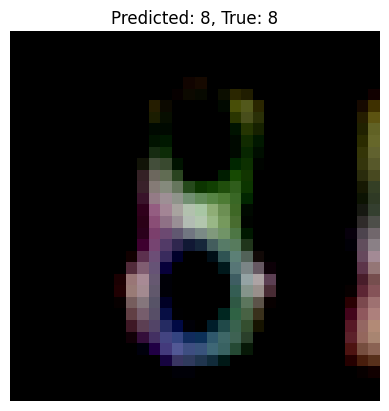

In [9]:
    # Plot and save an example image
    plot_image(testset, model, classes)